# CLUSTERING

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [131]:
x, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [132]:
df = pd.DataFrame(x, columns=['Feature 1', 'Feature 2'])
df

,Feature 1,Feature 2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [133]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(df)

In [134]:
inertia = []
k_range = range(1, 11)

In [135]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [136]:
inertia

[1000.0,
 297.8954141051721,
 11.575484723104983,
 9.752067977356845,
 8.257175272446283,
 6.917577320416798,
 6.334755391595289,
 5.704177177901429,
 5.060234133532076,
 4.762361898130399]

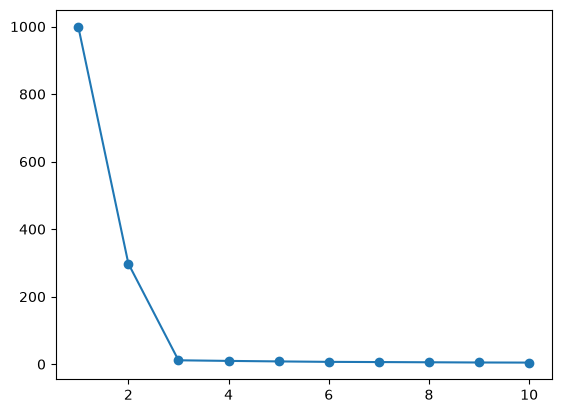

In [137]:
plt.plot(k_range, inertia, marker='o')

In [138]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [139]:
Cluster_label = kmeans_final.fit_predict(x_scaled)

In [140]:
Cluster_label

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [141]:
df['cluster'] = Cluster_label

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

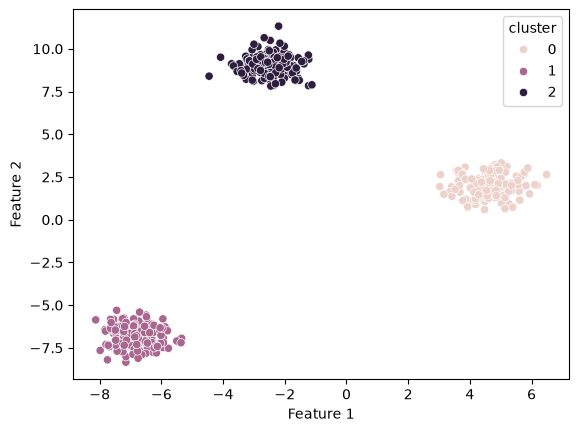

In [142]:
sns.scatterplot(x=df['Feature 1'],
                y=df['Feature 2'],
                hue=df['cluster']
) 

# Density Based SCAN

In [143]:
from sklearn.datasets import make_moons

In [144]:
x, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [145]:
from sklearn.cluster import KMeans, DBSCAN

In [146]:
df2 = pd.DataFrame(x, columns=['Feature 1', 'Feature 2'])

In [147]:
x_scaled2 = scalar.fit_transform(df2)

In [148]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_label = kmeans.fit_predict(x_scaled2)

In [149]:
df2['kmeans_cluster'] = kmeans_label

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

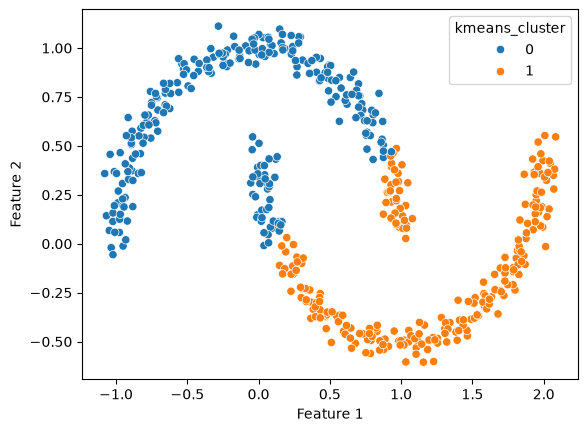

In [150]:
sns.scatterplot(x=df2['Feature 1'], 
                y=df2['Feature 2'],
                hue=df2['kmeans_cluster'])

In [151]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_label = dbscan.fit_predict(x_scaled2)

In [152]:
df2['dbscan_cluster'] = dbscan_label

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

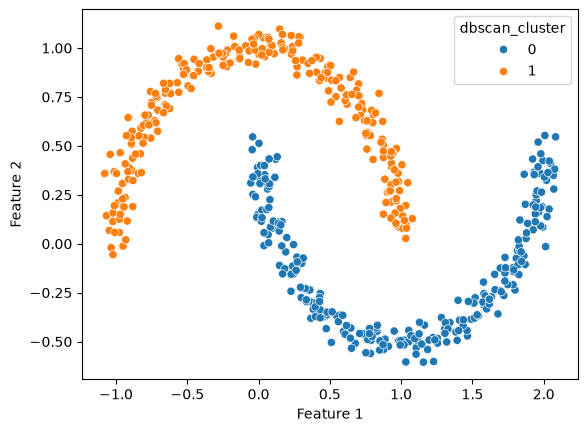

In [153]:
sns.scatterplot(x=df2['Feature 1'], 
                y=df2['Feature 2'],
                hue=df2['dbscan_cluster'])

# Dimensionality Reduction

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [155]:
x, y = make_blobs(n_samples=500, n_features=5, centers=3, 
                  cluster_std=0.6, random_state=42)

In [156]:
x

array([[-9.6958364 ,  9.44770466,  6.55203419, -6.17896116, -6.96231856],
       [-8.97185719,  8.99996482,  6.55309608, -5.18623479, -6.49925718],
       [-3.00028215,  8.11262712,  4.48343774,  1.29791828, -6.96904919],
       ...,
       [-6.45928575, -8.21969001,  7.38864852,  2.29987604,  5.43216513],
       [-2.50011166,  9.27953054,  5.26869068,  1.59602784, -7.14632644],
       [-7.58367155, -9.57840862,  7.74052166,  3.19022594,  4.00515242]],
      shape=(500, 5))

In [157]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

In [158]:
x_scaled

array([[-1.12937471,  0.73936542,  0.25536042, -1.51767371, -0.76613646],
       [-0.88716838,  0.68665398,  0.2561749 , -1.24936973, -0.67556887],
       [ 1.11061452,  0.58218963, -1.33128703,  0.5031012 , -0.76745287],
       ...,
       [-0.04659077, -1.34057871,  0.89705734,  0.77390015,  1.65803151],
       [ 1.27794593,  0.71956664, -0.72898513,  0.58367122, -0.80212554],
       [-0.42275262, -1.50053771,  1.16694981,  1.01453487,  1.37893005]],
      shape=(500, 5))

In [159]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

In [160]:
x_pca

array([[-0.71595688, -2.06122274],
       [-0.64778785, -1.70873989],
       [-1.62871485,  1.22631587],
       [ 2.00393843,  0.57623945],
       [-0.44534193, -1.99786329],
       [-1.56560602,  1.2075044 ],
       [-1.70853676,  1.57730144],
       [ 2.81542273,  0.50980482],
       [ 1.61916394,  0.87488653],
       [-1.18663445,  1.15615861],
       [-1.97781997,  1.55311469],
       [-1.63478894,  1.69766843],
       [ 2.10937496,  0.56794585],
       [-0.72460432, -1.86851746],
       [-0.51458134, -1.68621197],
       [-0.83107608, -2.03203037],
       [ 2.55438841,  0.17914803],
       [ 2.15459708,  0.51168645],
       [-1.87147902,  1.90163992],
       [-0.9315649 , -1.90883265],
       [-1.93815988,  1.30320855],
       [ 2.03955165,  0.56967077],
       [ 2.05927606,  0.68146409],
       [-0.33773996, -1.95448066],
       [-1.48554205,  1.38881472],
       [-0.45892647, -1.92177003],
       [ 2.19973027,  0.44162268],
       [ 2.11016439,  0.69820172],
       [-0.92014507,

In [161]:
df_pca = pd.DataFrame(x_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

In [163]:
df_pca

,PC1,PC2,label
0,-0.715957,-2.061223,2
1,-0.647788,-1.708740,2
2,-1.628715,1.226316,0
3,2.003938,0.576239,1
4,-0.445342,-1.997863,2
...,...,...,...
495,-1.647480,1.669963,0
496,-1.322440,1.287616,0
497,2.318513,0.719911,1
498,-1.455987,1.148050,0


<Axes: xlabel='PC1', ylabel='PC2'>

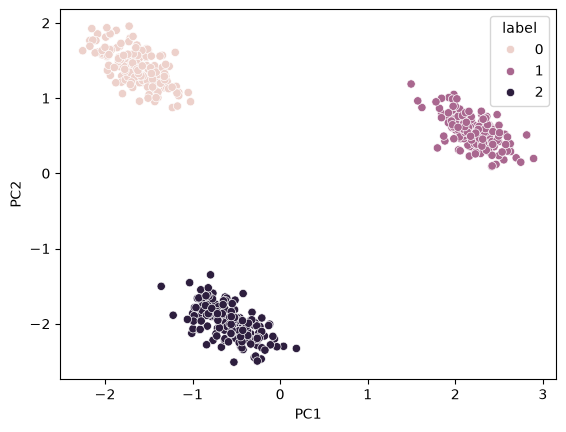

In [162]:
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label')